# PerLeadCNN — Exploratory Data Analysis

This notebook explores the 12-lead ECG cohort used to develop **PerLeadCNN**
and **justifies the concrete design choices** baked into `src/data.py`
(preprocessing, downsampling, patient-grouped splits) and `src/model.py`
(weight-shared per-lead backbone, kernel sizes, global pooling + late fusion).

It is deliberately *not* a grab-bag of plots. Every section follows the same
shape:

> **Question → evidence (figure/number) → the design decision it justifies.**

It reuses the exact loading/preprocessing code from `src.data`, so what we
look at here is what the model is actually trained on — no re-implemented
operations.

**Cohort (after cleaning, from `src.data.load_ecg_data`):**

- **2,178** twelve-lead recordings from **1,383** patients
- **335** preeclampsia (**15.4%**) — the rest normal
- **12 leads** (I, II, III, aVR, aVL, aVF, V1–V6), **2,500 samples @ 250 Hz = 10 s** per recording (model input)

> **Note.** The ECG data is PHI and not shipped (see `DATA.md`). Set
> `REPNET_DATA_DIR` to a directory in the expected layout to run this notebook.

## 0. Imports & constants

In [1]:
import os, sys, warnings
sys.path.insert(0, os.path.abspath('.'))   # make the `src` package importable

# Point at the ECG dataset (PHI, not shipped — see DATA.md). Override by
# exporting REPNET_DATA_DIR before launching the notebook.
os.environ.setdefault(
    'REPNET_DATA_DIR', os.path.abspath(os.path.join('..', 'data', 'seniordesign_upload')))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch, butter, iirnotch, tf2sos, sosfiltfilt

from src.data import (load_ecg_data, preprocess, resolve_data_dir,
                      SD_LEAD_ORDER, SD_LABEL_POS, DOWNSAMPLE, FS,
                      test_split, train_val_test_split)

LEADS = SD_LEAD_ORDER
FS_MODEL = FS / DOWNSAMPLE            # 250 Hz after the x2 downsample
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3,
                     'axes.spines.top': False, 'axes.spines.right': False})
POS, NEG = '#c0392b', '#2c7fb8'      # consistent class colours
warnings.filterwarnings('ignore')
print('data dir:', os.path.relpath(resolve_data_dir()))   # relative — no absolute home path

data dir: ../data/seniordesign_upload


## 1. Cohort & label definition

**Question:** what counts as a positive case, and how prevalent is it?

The label is read straight from `metadata.csv`. A recording is **positive**
iff its `PatLabel` is exactly the preeclampsia string; everything else is
negative. We look at the raw label distribution before any modelling.

In [2]:
meta = pd.read_csv(os.path.join(resolve_data_dir(), 'metadata.csv'))
ekg_dir = os.path.join(resolve_data_dir(), 'ekg_data')
have_csv = {int(os.path.splitext(f)[0]) for f in os.listdir(ekg_dir) if f.endswith('.csv')}

print(f'metadata rows                : {len(meta):>6}')
print(f'rows with a matching waveform: {meta["ECGTestID"].isin(have_csv).sum():>6}')
print(f'\npositive label string: "{SD_LABEL_POS}"\n')
print('PatLabel value counts:')
print(meta['PatLabel'].value_counts(dropna=False).head(6).to_string())

metadata rows                :   2483
rows with a matching waveform:   2191

positive label string: "Preeclampsia or Other Hypertensive Disorders of Pregnancy"

PatLabel value counts:
PatLabel
Normal_All                                                   2090
Preeclampsia or Other Hypertensive Disorders of Pregnancy     393


## 2. Load the modelling dataset (the *same* pipeline as training)

We load once with `load_ecg_data` (raw, 500 Hz, no filtering), then apply the
exact `preprocess` + `::DOWNSAMPLE` steps `load_dataset` uses. Keeping the raw
array lets us show the preprocessing *stages* later without re-reading 2,000+
files.

- `Xraw` : `(N, 12, 5000)` @ 500 Hz, no filtering — for the pipeline-stage plots
- `Xf`   : filtered + per-lead z-scored @ 500 Hz
- `Xm`   : `Xf[:, :, ::2]` → `(N, 12, 2500)` @ 250 Hz — **the model input**

In [3]:
Xraw, y, groups, is_up = load_ecg_data()
Xf = preprocess(Xraw)                 # 0.5 Hz high-pass + 60 Hz notch + z-score
Xm = Xf[:, :, ::DOWNSAMPLE]           # downsample to 250 Hz == load_dataset() output

N = len(y)
print(f'Xraw {Xraw.shape} @ {FS:.0f} Hz   ->   Xm {Xm.shape} @ {FS_MODEL:.0f} Hz')
print(f'{N} recordings | {int(y.sum())} positive ({y.mean():.1%}) | '
      f'{len(np.unique(groups))} patients')

Xraw (2178, 12, 5000) @ 500 Hz   ->   Xm (2178, 12, 2500) @ 250 Hz
2178 recordings | 335 positive (15.4%) | 1383 patients


## 3. Class imbalance → metric & operating-point choice

**Question:** is the dataset balanced, and what does that mean for evaluation?

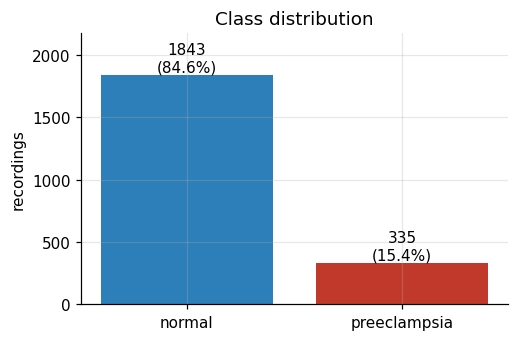

Prevalence: 15.4% positive.
A trivial "always normal" classifier scores 84.6% accuracy — yet
catches zero preeclampsia cases. Accuracy is therefore the wrong metric.


In [4]:
counts = np.bincount(y)
maj = counts.max() / counts.sum()

fig, ax = plt.subplots(figsize=(5, 3.2))
bars = ax.bar(['normal', 'preeclampsia'], counts, color=[NEG, POS])
for b, c in zip(bars, counts):
    ax.text(b.get_x() + b.get_width()/2, c, f'{c}\n({c/counts.sum():.1%})',
            ha='center', va='bottom')
ax.set_ylabel('recordings'); ax.set_title('Class distribution'); ax.set_ylim(0, counts.max()*1.18)
plt.show()

print(f'Prevalence: {y.mean():.1%} positive.')
print(f'A trivial "always normal" classifier scores {maj:.1%} accuracy — yet')
print('catches zero preeclampsia cases. Accuracy is therefore the wrong metric.')

**Decision.** The 15.4% prevalence makes **accuracy meaningless** (a do-nothing
model scores ~85%). The release therefore reports **AUROC** and **AUPRC**
(threshold-free, prevalence-aware) and selects two clinically meaningful
operating points in `src/metrics.py`: **Youden's J** and a **sensitivity ≥ 80%
screening point** (reported with **NPV**, the quantity a screening tool must
maximise). Imbalance also motivates **patient-grouped, *stratified*** splits
(next section) so every fold preserves this ratio.

## 4. Patient ↔ recording structure → patient-grouped splits

**Question:** do patients contribute more than one recording, and is the label
defined per-patient? If so, a naive recording-level split leaks a patient
across train and test.

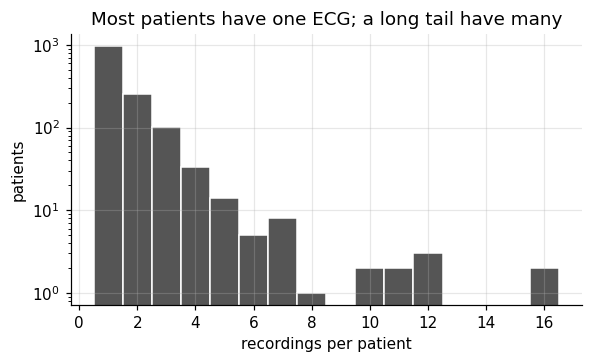

patients                       : 1383
patients with >1 recording     : 428  (max 16 recordings)
patients with mixed labels     : 0  (label is patient-level)

random 20% recording split -> 184 patients appear in BOTH train and test (leakage).


StratifiedGroupKFold split 0 -> 0 shared patients.


In [5]:
rec_per_pat = pd.Series(groups).value_counts()
df = pd.DataFrame({'pid': groups, 'y': y})
per_pat = df.groupby('pid')['y'].agg(['min', 'max'])
n_multi = int((rec_per_pat > 1).sum())
n_mixed = int((per_pat['min'] != per_pat['max']).sum())

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.hist(rec_per_pat.values, bins=np.arange(0.5, rec_per_pat.max()+1.5),
        color='#555', edgecolor='white')
ax.set_xlabel('recordings per patient'); ax.set_ylabel('patients')
ax.set_title('Most patients have one ECG; a long tail have many')
ax.set_yscale('log')
plt.show()

print(f'patients                       : {len(rec_per_pat)}')
print(f'patients with >1 recording     : {n_multi}  (max {rec_per_pat.max()} recordings)')
print(f'patients with mixed labels     : {n_mixed}  (label is patient-level)')

# Demonstrate the leakage a random recording-level split would cause.
rng = np.random.RandomState(0)
te = rng.rand(N) < 0.2
shared = len(set(groups[te]) & set(groups[~te]))
print(f'\nrandom 20% recording split -> {shared} patients appear in BOTH train and test (leakage).')
gte = test_split(0, y, groups)
gtr = np.setdiff1d(np.arange(N), gte)
print(f'StratifiedGroupKFold split 0 -> {len(set(groups[gte]) & set(groups[gtr]))} shared patients.')

**Decision.** Hundreds of patients contribute multiple recordings (up to 16),
and labels are strictly patient-level (zero mixed). A random recording split
puts the *same patient* in train and test — an optimistic, leaked estimate.
`src/data.py` therefore uses **`StratifiedGroupKFold` grouped by
`Pat_Obfus_MRN`**, giving **0 shared patients** while preserving class balance.
All 30 splits follow this scheme.

## 5. Raw recording integrity → resampling & cleaning

**Question:** are all recordings stored identically, and are any degenerate?

In [6]:
print(f'native length 5000 (500 Hz)  : {(~is_up).sum()}')
print(f'native length 2500 (resampled up to 5000): {is_up.sum()}')
print(f'metadata rows with a waveform: {meta["ECGTestID"].isin(have_csv).sum()}')
print(f'recordings surviving cleaning: {N}  '
      f'(dropped non-finite / flat-lead / unlabelled-patient records)')

# How close are any leads to flat? (std on raw ADC counts)
raw_std = Xraw.std(axis=2)
print(f'\nmin per-lead raw std across the cohort: {raw_std.min():.3f} '
      f'(the loader drops any record with a lead std < 1e-4)')

native length 5000 (500 Hz)  : 1780
native length 2500 (resampled up to 5000): 398
metadata rows with a waveform: 2191
recordings surviving cleaning: 2178  (dropped non-finite / flat-lead / unlabelled-patient records)



min per-lead raw std across the cohort: 7.877 (the loader drops any record with a lead std < 1e-4)


**Decision.** Recordings arrive at **two native lengths** (2,500 and 5,000
samples). `load_ecg_data` **resamples the 2,500-sample records up to 5,000**
*before* filtering, so the filter design (in Hz) is identical for every
record. It then **drops non-finite values and flat (dead) leads** — these would
produce NaNs after z-scoring or contribute pure noise — and drops records whose
patient id is missing (can't be grouped).

## 6. Preprocessing stages on one recording

**Question:** what does each preprocessing step actually do to a waveform?

We take one fixed recording and show lead II at three stages: **raw**,
**+ 0.5 Hz high-pass + 60 Hz notch**, and **+ per-lead z-score** (the model
input).

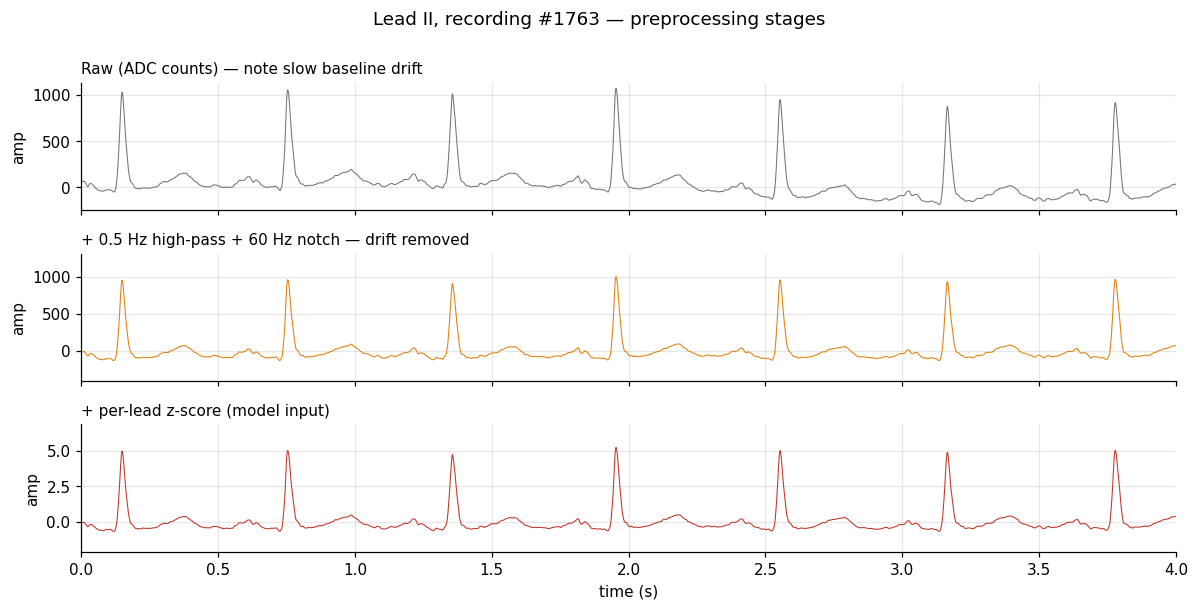

In [7]:
i = int(np.argmax(y))            # a fixed positive recording, for reproducibility
li = LEADS.index('II')
t_raw = np.arange(Xraw.shape[2]) / FS

# filtered-but-not-yet-z-scored, reusing the same filters as src.data.preprocess
def _filt(sig):
    s = sosfiltfilt(butter(4, 0.5, btype='high', fs=FS, output='sos'), sig)
    b, a = iirnotch(60.0, 30.0, fs=FS)
    return sosfiltfilt(tf2sos(b, a), s)

raw = Xraw[i, li]
filt = _filt(raw)
norm = Xf[i, li]

fig, axes = plt.subplots(3, 1, figsize=(11, 5.5), sharex=True)
for ax, sig, title, c in [
    (axes[0], raw,  'Raw (ADC counts) — note slow baseline drift', '#777'),
    (axes[1], filt, '+ 0.5 Hz high-pass + 60 Hz notch — drift removed', '#e08214'),
    (axes[2], norm, '+ per-lead z-score (model input)', POS)]:
    ax.plot(t_raw, sig, c, lw=0.7); ax.set_title(title, loc='left', fontsize=10)
    ax.set_ylabel('amp')
axes[-1].set_xlabel('time (s)'); axes[-1].set_xlim(0, 4)
fig.suptitle(f'Lead II, recording #{i} — preprocessing stages', y=1.0)
plt.tight_layout(); plt.show()

**Decision.** The raw trace carries slow **baseline wander** (respiration/motion
drift below ~0.5 Hz) and sits on an arbitrary ADC scale. The **4th-order
zero-phase 0.5 Hz high-pass** removes the drift without phase distortion; the
**60 Hz notch** is cheap insurance against mains interference; **per-lead
z-score** puts every lead on a comparable mean-0 / std-1 scale so the
weight-shared backbone sees consistent input. (Section 8 shows the notch is
*defensive* — this cohort carries little mains energy.)

## 7. Per-lead amplitude scale & distribution shape → z-score

**Question:** do leads share an amplitude scale (global norm OK), or differ
(per-lead norm needed)? And is z-score the right *kind* of normalization?

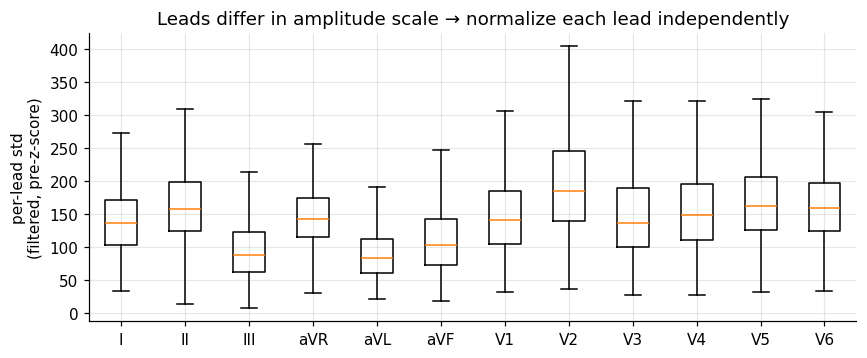

per-lead median std ranges 83–184 (2.2x across leads)


within-lead amplitude distribution: mean excess-kurtosis 15.4, mean |skew| 2.94  (heavy-tailed — the QRS spikes)


In [8]:
from scipy.stats import kurtosis, skew
# scale on filtered-but-unnormalized data (z-score would erase scale by construction)
filt_all = sosfiltfilt(butter(4, 0.5, btype='high', fs=FS, output='sos'), Xraw, axis=2)
lead_std = filt_all.std(axis=2)                    # (N, 12)

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.boxplot([lead_std[:, k] for k in range(12)], tick_labels=LEADS, showfliers=False)
ax.set_ylabel('per-lead std\n(filtered, pre-z-score)')
ax.set_title('Leads differ in amplitude scale → normalize each lead independently')
plt.show()

med = np.median(lead_std, axis=0)
print(f'per-lead median std ranges {med.min():.0f}–{med.max():.0f} '
      f'({med.max()/med.min():.1f}x across leads)')
ku = kurtosis(filt_all.reshape(-1, filt_all.shape[2]).T).mean()  # over time, per lead-record
sk = np.abs(skew(filt_all.reshape(-1, filt_all.shape[2]).T)).mean()
print(f'within-lead amplitude distribution: mean excess-kurtosis {ku:.1f}, '
      f'mean |skew| {sk:.2f}  (heavy-tailed — the QRS spikes)')

**Decision.** Median per-lead amplitude varies ~2× across leads (e.g. limb
leads vs V2), so a *global* normalization would let high-amplitude leads
dominate the shared backbone. `preprocess` therefore z-scores **each lead
independently**. The within-lead distribution is heavily **non-Gaussian**
(excess-kurtosis ≫ 0, large |skew|) — but that is *by design*: the heavy tail is
the sharp QRS complex, i.e. the signal we want to keep. That is exactly why we
use plain **mean/std z-score** rather than a robust/median or outlier-clipping
normalizer, which would suppress the QRS peaks that carry the diagnostic
information.

## 8. Spectral content → 60 Hz notch & ×2 downsample to 250 Hz

**Question:** where does the signal energy live? That decides (a) whether a
mains notch is needed and (b) how far we can safely downsample.

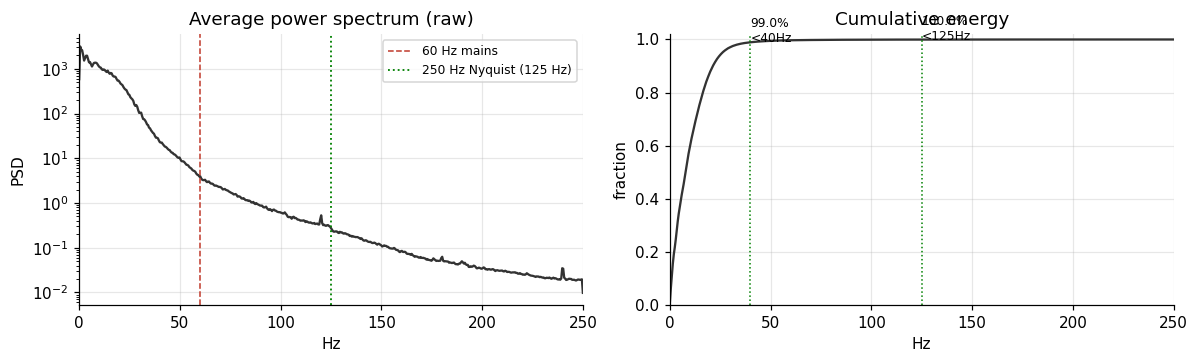

60 Hz power / 50–70 Hz neighbours: 0.62  (>1 would mean a mains peak; here it is not prominent)
energy below 40 Hz: 99.0%   below 125 Hz (250 Hz Nyquist): 100.0%


In [9]:
idx = np.random.RandomState(0).choice(N, min(400, N), replace=False)
freqs, P = welch(Xraw[idx], fs=FS, nperseg=1024, axis=2)
Pm = P.mean(axis=(0, 1))
cum = np.cumsum(Pm) / Pm.sum()

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.4))
a1.semilogy(freqs, Pm, '#333'); a1.axvline(60, color=POS, ls='--', lw=1, label='60 Hz mains')
a1.axvline(FS_MODEL/2, color='green', ls=':', lw=1.2, label=f'250 Hz Nyquist ({FS_MODEL/2:.0f} Hz)')
a1.set_xlim(0, 250); a1.set_xlabel('Hz'); a1.set_ylabel('PSD'); a1.legend(fontsize=8)
a1.set_title('Average power spectrum (raw)')

a2.plot(freqs, cum, '#333')
for c in (40, FS_MODEL/2):
    a2.axvline(c, ls=':', lw=1, color='green')
    a2.annotate(f'{cum[np.searchsorted(freqs, c)]:.1%}\n<{c:.0f}Hz',
                (c, cum[np.searchsorted(freqs, c)]), fontsize=8)
a2.set_xlim(0, 250); a2.set_ylim(0, 1.02); a2.set_xlabel('Hz')
a2.set_title('Cumulative energy'); a2.set_ylabel('fraction')
plt.tight_layout(); plt.show()

i60 = np.argmin(np.abs(freqs-60))
base = (Pm[np.argmin(np.abs(freqs-50))] + Pm[np.argmin(np.abs(freqs-70))]) / 2
print(f'60 Hz power / 50–70 Hz neighbours: {Pm[i60]/base:.2f}  '
      f'(>1 would mean a mains peak; here it is not prominent)')
print(f'energy below 40 Hz: {cum[np.searchsorted(freqs,40)]:.1%}   '
      f'below 125 Hz (250 Hz Nyquist): {cum[np.searchsorted(freqs,125)]:.1%}')

**Decision.** Two choices fall out of the spectrum:

- **60 Hz notch is defensive, not corrective.** This cohort shows *no* prominent
  mains peak (60 Hz power ≈ its neighbours), so the notch costs almost nothing
  here but standardizes the pipeline for noisier recordings.
- **×2 downsample to 250 Hz is free.** ~99% of energy sits below 40 Hz and
  essentially **100% below the 250 Hz Nyquist (125 Hz)**, so dropping every
  other sample discards no diagnostic content while **halving the input length**
  (5,000 → 2,500) — fewer FLOPs and parameters for the same information.

## 9. Morphology scale & alignment → kernels, stride, and global pooling

**Question:** at what temporal scale do the classes differ, and is that
difference pinned to a fixed location in the strip (so position matters) or
spread out (so the model should be position-invariant)?

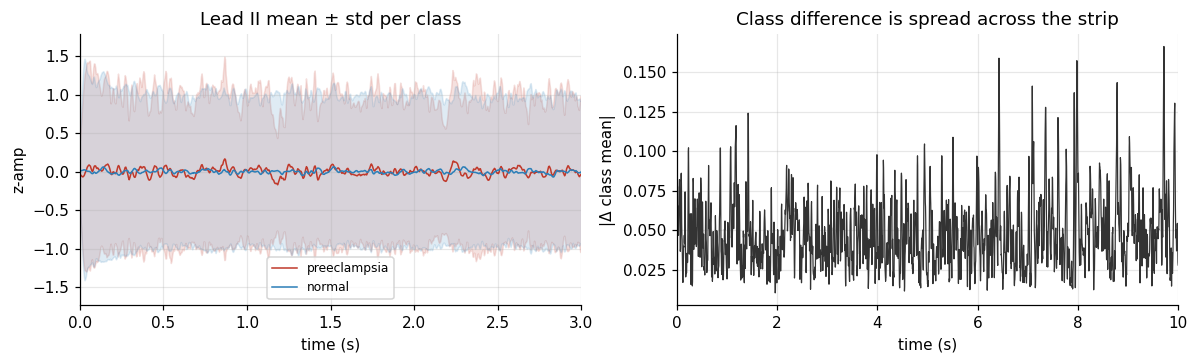

within-class std >> between-class mean difference (overlapping bands above).
PerLeadCNN receptive field: 111 samples = 444 ms @ 250 Hz (~one cardiac cycle).


In [10]:
t = np.arange(Xm.shape[2]) / FS_MODEL
mp, mn = Xm[y == 1].mean(0), Xm[y == 0].mean(0)
sp, sn = Xm[y == 1].std(0),  Xm[y == 0].std(0)
li = LEADS.index('II')

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.4))
for m, s, c, lab in [(mp[li], sp[li], POS, 'preeclampsia'), (mn[li], sn[li], NEG, 'normal')]:
    a1.plot(t, m, c, lw=1, label=lab); a1.fill_between(t, m-s, m+s, color=c, alpha=0.15)
a1.set_xlim(0, 3); a1.set_xlabel('time (s)'); a1.set_ylabel('z-amp')
a1.set_title('Lead II mean ± std per class'); a1.legend(fontsize=8)

diff = np.abs(mp - mn).mean(0)              # |class-mean diff| averaged over leads
a2.plot(t, diff, '#333', lw=0.8)
a2.set_xlim(0, 10); a2.set_xlabel('time (s)'); a2.set_ylabel('|Δ class mean|')
a2.set_title('Class difference is spread across the strip')
plt.tight_layout(); plt.show()

# theoretical receptive field of Conv kernels (31,21,11), stride 2 each
rf, jump = 1, 1
for k in (31, 21, 11):
    rf += (k-1)*jump; jump *= 2
print(f'within-class std >> between-class mean difference (overlapping bands above).')
print(f'PerLeadCNN receptive field: {rf} samples = {rf/FS_MODEL*1000:.0f} ms @ 250 Hz '
      f'(~one cardiac cycle).')

**Decision.** Beats are **not R-peak aligned** across recordings, so the
class-mean difference is **smeared across the whole strip** (right panel) rather
than concentrated at one latency, and within-class variability dwarfs the
between-class mean shift (overlapping bands, left panel). Two design
consequences:

- The discriminative cue is **local waveform morphology, not its position** →
  PerLeadCNN uses **convolutions followed by global average pooling**, which is
  translation-invariant over the 10 s strip.
- Kernels of **31 → 21 → 11** with **stride 2** give a **~444 ms receptive
  field** — about one full cardiac cycle — so the backbone can see complete
  PQRST morphology while the decreasing kernel/stride schedule keeps the model
  compact (29,490 params).

## 10. Lead discriminability & inter-lead coupling → shared backbone + late fusion

**Question:** does one lead carry the signal (→ pick it / attend to it), or do
all 12 contribute weakly? And does preeclampsia change the *coupling* between
leads (→ a cross-lead 2D conv would help)?

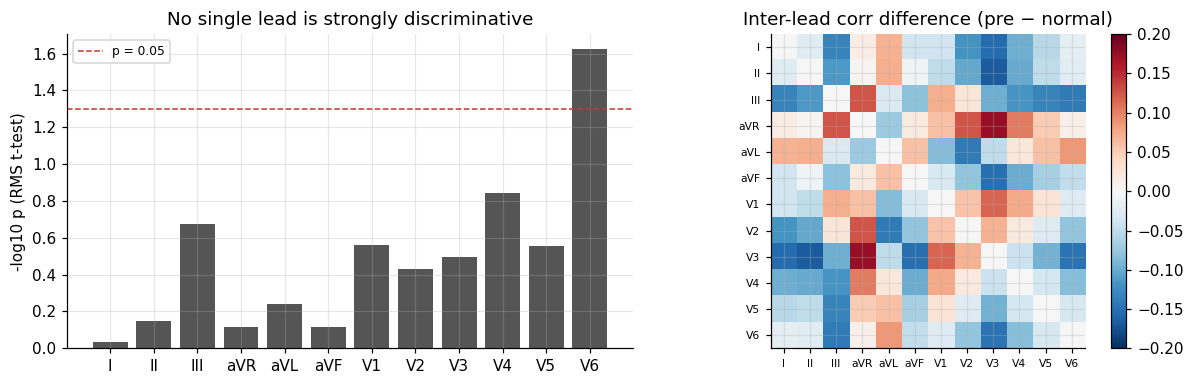

max per-lead -log10 p: 1.6 (1/12 leads pass p<0.05 on RMS alone)
inter-lead corr |difference| off-diagonal: mean 0.073, max 0.174


In [11]:
from scipy.stats import ttest_ind
rms = np.sqrt((Xm**2).mean(axis=2))            # (N, 12)
nlp = [(-np.log10(max(ttest_ind(rms[y==1, k], rms[y==0, k], equal_var=False)[1], 1e-300)))
       for k in range(12)]

def mean_corr(Xc):
    C = np.zeros((12, 12))
    for r in Xc: C += np.corrcoef(r)
    return C / len(Xc)
Cp, Cn = mean_corr(Xm[y == 1]), mean_corr(Xm[y == 0])
dC = Cp - Cn

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6),
                         gridspec_kw={'width_ratios': [1.1, 1]})
axes[0].bar(LEADS, nlp, color='#555')
axes[0].axhline(-np.log10(0.05), color=POS, ls='--', lw=1, label='p = 0.05')
axes[0].set_ylabel('-log10 p (RMS t-test)'); axes[0].legend(fontsize=8)
axes[0].set_title('No single lead is strongly discriminative')

im = axes[1].imshow(dC, cmap='RdBu_r', vmin=-0.2, vmax=0.2)
axes[1].set_xticks(range(12)); axes[1].set_xticklabels(LEADS, fontsize=7)
axes[1].set_yticks(range(12)); axes[1].set_yticklabels(LEADS, fontsize=7)
axes[1].set_title('Inter-lead corr difference (pre − normal)')
fig.colorbar(im, ax=axes[1], fraction=0.046)
plt.tight_layout(); plt.show()

iu = np.triu_indices(12, 1)
print(f'max per-lead -log10 p: {max(nlp):.1f} '
      f'({sum(v > -np.log10(0.05) for v in nlp)}/12 leads pass p<0.05 on RMS alone)')
print(f'inter-lead corr |difference| off-diagonal: mean {np.abs(dC[iu]).mean():.3f}, '
      f'max {np.abs(dC[iu]).max():.3f}')

**Decision.** Two observations drive the architecture:

- **No lead dominates.** Per-lead RMS barely separates the classes (max
  −log10 p ≈ 1.6; almost no lead passes p < 0.05 on a simple feature). There is
  no basis to cherry-pick a lead or add a per-lead attention gate → use a
  **single weight-shared 1D backbone applied identically to all 12 leads**, and
  let the final linear layer learn how to weight them.
- **Coupling is nearly class-invariant.** The inter-lead correlation structure
  hardly differs between classes (|Δ| ≈ 0.07), so an expensive **cross-lead 2D
  convolution is not justified**. PerLeadCNN keeps leads **independent through
  the backbone** and fuses them only at the end by **concatenating the 12
  per-lead feature vectors** (12 × 48 = 576) into one linear classifier.

## 11. Summary — finding → design decision

| # | Finding in the data | Decision in the code |
|---|---|---|
| 3 | 15.4% prevalence; accuracy is meaningless | AUROC/AUPRC + Youden & sens≥80% (NPV) operating points |
| 4 | 428 patients have ≥2 recordings; labels are patient-level | **patient-grouped** `StratifiedGroupKFold` (no leakage) |
| 5 | mixed native lengths (2,500 / 5,000); some dead leads | resample 2,500→5,000 before filtering; drop flat/non-finite |
| 6–7 | baseline drift; per-lead scale differs ~2× | 0.5 Hz high-pass + **per-lead** z-score |
| 8 | ~99% energy < 40 Hz; no mains peak | ×2 downsample to 250 Hz (free); 60 Hz notch as insurance |
| 9 | beats unaligned; difference spread across strip | conv + **global average pool** (translation-invariant); 444 ms RF kernels |
| 10 | no dominant lead; coupling ≈ class-invariant | **weight-shared per-lead backbone** + late concat-fusion (not 2D cross-lead conv) |

Every architectural and preprocessing choice in `PerLeadCNN` traces back to a
property of this cohort — not to arbitrary tuning. To reproduce the model's
reported metrics from these same inputs, see `reproduce.ipynb`; to retrain, see
`train.ipynb`.